<a href="https://colab.research.google.com/github/harshal8704/NNDL-Practicals/blob/main/NNDL_Prac6.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.preprocessing import MinMaxScaler
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import LSTM, RepeatVector, TimeDistributed, Dense
from tensorflow.keras.callbacks import EarlyStopping

# Note: If running in Colab, mount drive and load your CSV here:
# from google.colab import drive
# drive.mount('/content/drive')
# df = pd.read_csv('/content/drive/MyDrive/your_data.csv')

# --- CREATING DUMMY DATA FOR TESTING (Replace with your df loading above) ---
dates = pd.date_range(start='2023-01-01', periods=1000, freq='H')
# Normal pattern with a few injected anomaly spikes
aqi_values = np.sin(np.linspace(0, 50, 1000)) * 50 + 100 + np.random.normal(0, 5, 1000)
aqi_values[400:410] += 150  # Inject anomaly 1
aqi_values[800:815] -= 80   # Inject anomaly 2
df = pd.DataFrame({'Date': dates, 'AQI Value': aqi_values})
# -------------------------------------------------------------------------

# Preprocess Dates
df['Date'] = pd.to_datetime(df['Date'])
df = df.sort_values(by='Date').reset_index(drop=True)

# Scale Data (0 to 1)
scaler = MinMaxScaler()
data_scaled = scaler.fit_transform(df[['AQI Value']])

print("Data scaled successfully. Shape:", data_scaled.shape)

Data scaled successfully. Shape: (1000, 1)


/tmp/ipykernel_1915/814951383.py:16: FutureWarning: 'H' is deprecated and will be removed in a future version, please use 'h' instead.
  dates = pd.date_range(start='2023-01-01', periods=1000, freq='H')


In [ ]:
# Function to create time-series sequences
def create_sequences(data, timesteps):
    X = [data[i:(i + timesteps)] for i in range(len(data) - timesteps)]
    return np.array(X)

timesteps = 30
X = create_sequences(data_scaled, timesteps)

print(f"Shape of input sequences: {X.shape}")
print(f"First sequence shape: {X[0].shape}")

Shape of input sequences: (970, 30, 1)
First sequence shape: (30, 1)


/usr/local/lib/python3.13/dist-packages/keras/src/layers/rnn/rnn.py:199: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(**kwargs)


Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ lstm (LSTM)                     │ (None, 16)             │         1,152 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ repeat_vector (RepeatVector)    │ (None, 30, 16)         │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ lstm_1 (LSTM)                   │ (None, 30, 16)         │         2,112 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ time_distributed                │ (None, 30, 1)          │            17 │
│ (TimeDistributed)               │                        │               │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 3,281 (12.82 KB)

 Trainable params: 3,281 (12.82 KB)

 Non-trainable params: 0 (0.00 B)

None
Epoch 1/50
25/25 ━━━━━━━━━━━━━━━━━━━━ 7s 76ms/step - loss: 0.1890 - val_loss: 0.1043
Epoch 2/50
25/25 ━━━━━━━━━━━━━━━━━━━━ 1s 28ms/step - loss: 0.0966 - val_loss: 0.0935
Epoch 3/50
25/25 ━━━━━━━━━━━━━━━━━━━━ 1s 47ms/step - loss: 0.0856 - val_loss: 0.0822
Epoch 4/50
25/25 ━━━━━━━━━━━━━━━━━━━━ 2s 68ms/step - loss: 0.0723 - val_loss: 0.0692
Epoch 5/50
25/25 ━━━━━━━━━━━━━━━━━━━━ 2s 66ms/step - loss: 0.0643 - val_loss: 0.0651
Epoch 6/50
25/25 ━━━━━━━━━━━━━━━━━━━━ 1s 27ms/step - loss: 0.0590 - val_loss: 0.0599
Epoch 7/50
25/25 ━━━━━━━━━━━━━━━━━━━━ 1s 26ms/step - loss: 0.0536 - val_loss: 0.0555
Epoch 8/50
25/25 ━━━━━━━━━━━━━━━━━━━━ 1s 29ms/step - loss: 0.0490 - val_loss: 0.0505
Epoch 9/50
25/25 ━━━━━━━━━━━━━━━━━━━━ 1s 27ms/step - loss: 0.0431 - val_loss: 0.0469
Epoch 10/50
25/25 ━━━━━━━━━━━━━━━━━━━━ 2s 45ms/step - loss: 0.0392 - val_loss: 0.0425
Epoch 11/50
25/25 ━━━━━━━━━━━━━━━━━━━━ 1s 49ms/step - loss: 0.0358 - val_loss: 0.0423
Epoch 12/50
25/25 ━━━━━━━━━━━━━━━━━━━━ 1s 41ms/step - loss

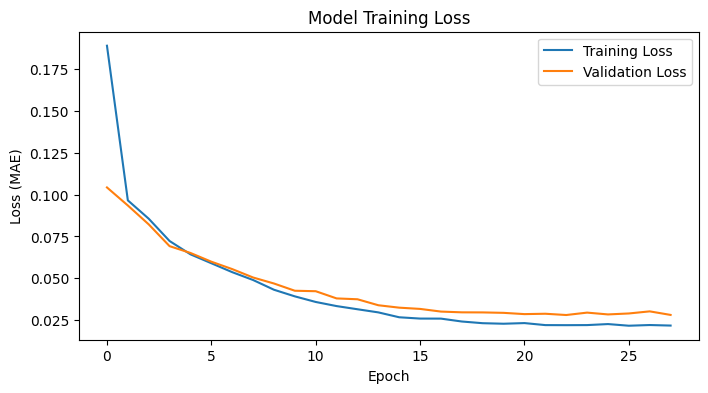

In [ ]:
# Build simpler Sequential Autoencoder
model = Sequential([
    LSTM(16, activation='relu', input_shape=(timesteps, 1), return_sequences=False),
    RepeatVector(timesteps),
    LSTM(16, activation='relu', return_sequences=True),
    TimeDistributed(Dense(1))
])

model.compile(optimizer='adam', loss='mae')
print(model.summary())

# Train the model
early_stopping = EarlyStopping(monitor='val_loss', patience=5, restore_best_weights=True)

history = model.fit(
    X, X,  # Target is the input itself
    epochs=50,
    batch_size=32,
    validation_split=0.2, # Automatically uses 20% of data for validation
    callbacks=[early_stopping],
    verbose=1
)

# Plot Training History
plt.figure(figsize=(8, 4))
plt.plot(history.history['loss'], label='Training Loss')
plt.plot(history.history['val_loss'], label='Validation Loss')
plt.title('Model Training Loss')
plt.ylabel('Loss (MAE)')
plt.xlabel('Epoch')
plt.legend()
plt.show()

31/31 ━━━━━━━━━━━━━━━━━━━━ 2s 45ms/step


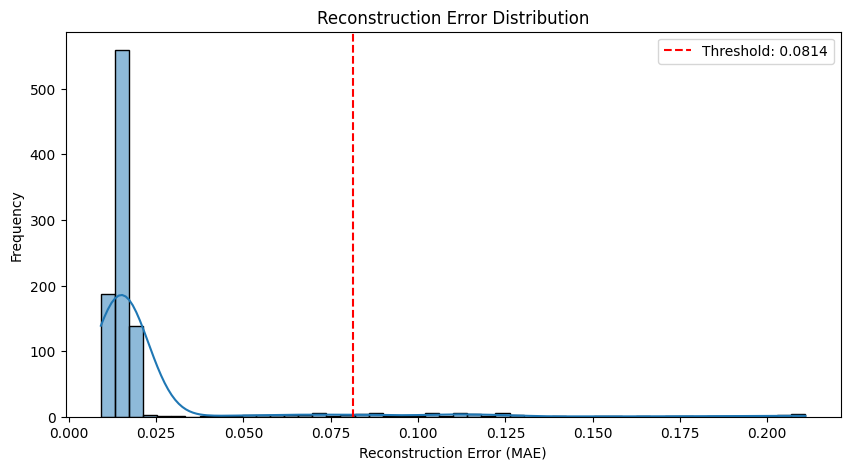

Calculated Threshold: 0.0814
Total anomalies detected: 54


In [ ]:
# Predict and calculate Mean Absolute Error (MAE)
X_pred = model.predict(X)
errors = np.mean(np.abs(X - X_pred), axis=(1, 2))

# Define anomaly threshold (Mean + 2 Standard Deviations)
threshold = np.mean(errors) + 2 * np.std(errors)

# Plot Error Distribution
plt.figure(figsize=(10, 5))
sns.histplot(errors, bins=50, kde=True)
plt.axvline(threshold, color='red', linestyle='--', label=f'Threshold: {threshold:.4f}')
plt.title('Reconstruction Error Distribution')
plt.xlabel('Reconstruction Error (MAE)')
plt.ylabel('Frequency')
plt.legend()
plt.show()

print(f"Calculated Threshold: {threshold:.4f}")
print(f"Total anomalies detected: {np.sum(errors > threshold)}")

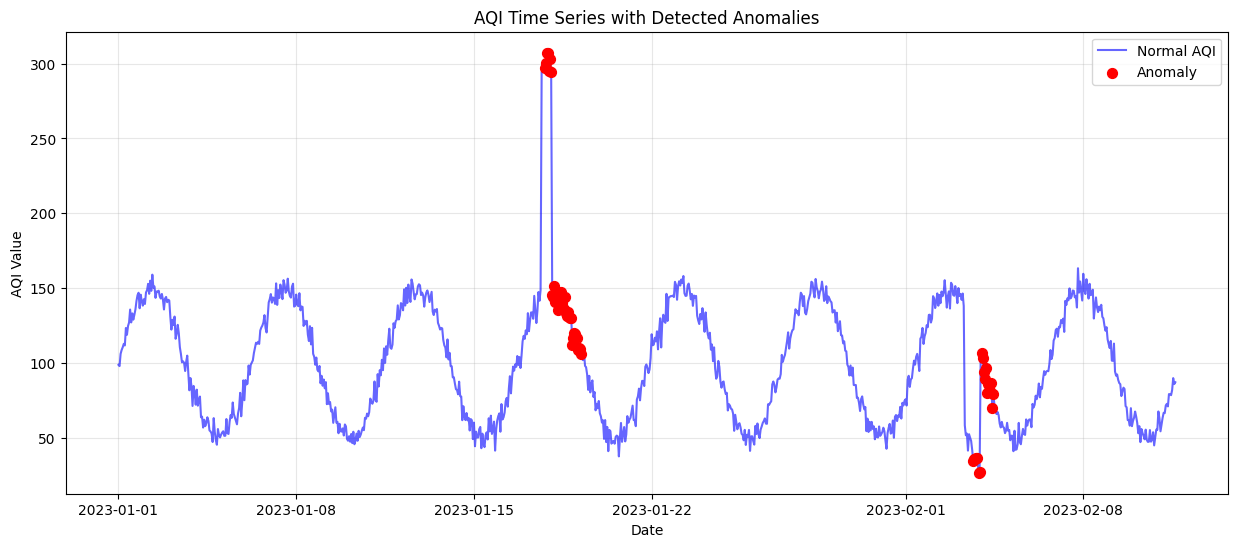

In [ ]:
# Align errors with original dataframe (skipping the first 'timesteps' rows)
df_results = df.iloc[timesteps:].copy()
df_results['Error'] = errors
df_results['Is_Anomaly'] = errors > threshold

# Plot Original Data with Anomalies Highlighted
plt.figure(figsize=(15, 6))
plt.plot(df['Date'], df['AQI Value'], label='Normal AQI', color='blue', alpha=0.6)

# Extract and plot only the anomalous points
anomalies = df_results[df_results['Is_Anomaly']]
plt.scatter(anomalies['Date'], anomalies['AQI Value'], color='red', label='Anomaly', s=50, zorder=5)

plt.title('AQI Time Series with Detected Anomalies')
plt.xlabel('Date')
plt.ylabel('AQI Value')
plt.legend()
plt.grid(True, alpha=0.3)
plt.show()